In [65]:
import ttide as tt
import numpy as np
import PyQt5
import pandas as pd
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

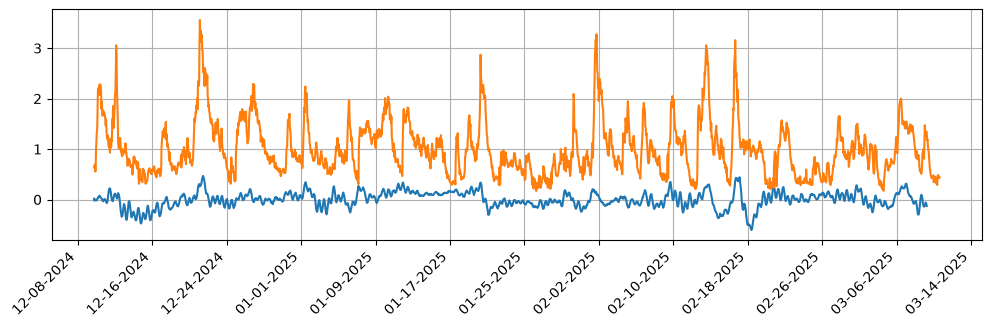

In [76]:
df_raw = pd.read_csv('Marconi_wave-data/sig1000_waves_ALL.txt',delimiter='\t',usecols=['time','water_depth','wh_4061'])
df_pred = pd.read_csv('Marconi_wave-data/sig1000_waves_ttide_predict.txt',delimiter='\t',usecols=['Time','Depth'])

df_raw.index=pd.to_datetime(df_raw['time'],)
df_pred.index=pd.to_datetime(df_pred['Time'])

start_date = df_raw.index[0]
end_date = df_raw.index[-1]


# 3. Get row integer locations (indices)
matching_indices = df_raw.index.get_indexer(df_pred.loc[start_date:end_date].index)


df_raw['pred']=df_pred['Depth'].iloc[matching_indices]

df_raw['diff'] = df_raw['water_depth']-df_raw['pred']


fig,ax = plt.subplots(figsize=(12,3))
ax.plot(df_raw.index,df_raw['diff'])
ax.plot(df_raw.index,df_raw['wh_4061'])
ax.xaxis.set_major_locator(mdates.DayLocator(interval=8))  # every day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True)
plt.show()